In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report, confusion_matrix,accuracy_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator

import itertools

In [ ]:
import os

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import LabelEncoder
import seaborn as sns




In [ ]:
import json

import tensorflow as tf
from tensorflow.keras.models import Sequential

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')



import joblib
import pickle
from pathlib import Path



In [ ]:
# ------------------------------
# Configuration
# ------------------------------


DATA_DIR = r"E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\core\data"
MODEL_DIR = [
    r"E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models"
    
]

# Data repository directory
DATA_REPO = os.path.join(DATA_DIR, "data_repo")
FEATURE_STORE=os.path.join(DATA_DIR, "feature_store")

# Input weather_data file
INPUT_FILE ={ 
    "regression": os.path.join(FEATURE_STORE, "reg_categorised_weather_data_with_features.csv"),
    "time_series": os.path.join(FEATURE_STORE, "ts_categorised_weather_data_with_features.csv"),  
    "other":[
        os.path.join(FEATURE_STORE, "rd_level_data_with_eng_features.csv"),
        os.path.join(FEATURE_STORE, "dock_level_data_with_eng_features.csv"),
        os.path.join(FEATURE_STORE, "traffic_for_lecture_system.csv")
    ]
}

OUTPUT_DIR = os.path.join(FEATURE_STORE, "reg_ts_categorised_weather_data_with_features.csv")
    
    


In [ ]:
# Load time series data and regression data
print(f"Reading input file: {INPUT_FILE}")
ts_df = pd.read_csv(INPUT_FILE["time_series"], encoding='utf-8', parse_dates=['datetime'])
reg_df = pd.read_csv(INPUT_FILE["regression"], encoding='utf-8', parse_dates=['datetime'])


Reading input file: {'regression': 'E:\\yr3\\year_3_ai_ml\\year_3_ai_ml\\dstse\\src\\core\\data\\feature_store\\reg_categorised_weather_data_with_features.csv', 'time_series': 'E:\\yr3\\year_3_ai_ml\\year_3_ai_ml\\dstse\\src\\core\\data\\feature_store\\ts_categorised_weather_data_with_features.csv', 'other': ['E:\\yr3\\year_3_ai_ml\\year_3_ai_ml\\dstse\\src\\core\\data\\feature_store\\rd_level_data_with_eng_features.csv', 'E:\\yr3\\year_3_ai_ml\\year_3_ai_ml\\dstse\\src\\core\\data\\feature_store\\dock_level_data_with_eng_features.csv', 'E:\\yr3\\year_3_ai_ml\\year_3_ai_ml\\dstse\\src\\core\\data\\feature_store\\traffic_for_lecture_system.csv']}


In [ ]:
# merge the two dataframes on 'datetime' and 'category'
merged_df = pd.merge(ts_df, reg_df, on=['datetime'], suffixes=('_ts', '_reg'))

In [ ]:
merged_df.to_csv(OUTPUT_DIR, index=False)
print("Saved data with categories to 'categorised_weather_data_with_features.csv'")

Saved data with categories to 'categorised_weather_data_with_features.csv'


In [ ]:
merged_df.head()

,Date,Time,Total Rainfall,Dry bulb,Wet bulb,Humidity,Wind speed,datetime,log_rainfall_ts,hour,...,rainfall_lag_2,humidity_lag_2,drybulb_lag_2,rainfall_lag_3,humidity_lag_3,drybulb_lag_3,rainfall_roll_3h,humidity_roll_3h,drybulb_roll_3h,log_rainfall_reg
0,3/1/2023,14:00,0.0,26.5,20.2,55.0,4,2023-03-01 14:00:00,0.000000,14,...,0.0,65.0,25.0,0.0,70.0,23.5,0.000000,58.333333,25.900000,0.000000
1,3/1/2023,15:00,0.0,27.4,20.6,53.0,6,2023-03-01 15:00:00,0.000000,15,...,0.0,55.0,26.2,0.0,65.0,25.0,0.000000,54.333333,26.700000,0.000000
2,3/1/2023,16:00,0.0,27.0,20.5,54.0,4,2023-03-01 16:00:00,0.000000,16,...,0.0,55.0,26.5,0.0,55.0,26.2,0.000000,54.000000,26.966667,0.000000
3,3/2/2023,8:00,83.3,19.8,18.4,88.0,0,2023-03-02 08:00:00,4.434382,8,...,0.0,53.0,27.4,0.0,55.0,26.5,27.766667,65.000000,24.733333,4.434382
4,3/2/2023,9:00,83.3,20.5,18.5,83.0,2,2023-03-02 09:00:00,4.434382,9,...,0.0,54.0,27.0,0.0,53.0,27.4,55.533333,75.000000,22.433333,4.434382


# WEATHER DATA MODEL TRAINGING AND EVALUATION

### RANDOM FOREST
### Regression with Random Forest (RF)
###### RF is a powerful ensemble learning method that combines multiple decision trees to improve predictive performance and reduce overfitting. It works by creating a "forest" of decision trees, where each tree is trained on a random subset of the data and features. The final prediction is made by aggregating the predictions from all the individual trees, typically through majority voting for classification tasks or averaging for regression tasks. RF is known for its robustness, ability to handle high-dimensional data, and effectiveness in capturing complex relationships between features.

In [ ]:
# Define feature columns 
feature_cols = [
    'Dry bulb', 'Wet bulb', 'Humidity', 'Wind speed',
    'dayofweek', 'hour', 'month','day',
    'rainfall_lag_1', 'rainfall_lag_2', 'rainfall_lag_3',
    'humidity_lag_1', 'humidity_lag_2', 'humidity_lag_3',
    'drybulb_lag_1', 'drybulb_lag_2', 'drybulb_lag_3',
    'rainfall_roll_3h', 'humidity_roll_3h', 'drybulb_roll_3h'
]

# ------------------------------
# 2. Temporal Train/Test Split
# ------------------------------
# Group by date to keep sequences intact
dates = merged_df['date'].unique()
dates = np.sort(dates)

split_idx = int(0.8 * len(dates))
train_dates = dates[:split_idx]
test_dates = dates[split_idx:]

train_mask = merged_df['date'].isin(train_dates)

test_mask = merged_df['date'].isin(test_dates)

X_train = merged_df.loc[train_mask, feature_cols]

print("shape of X_train:", X_train.shape)
print("X columns:", X_train.columns.tolist())

y_train_reg = merged_df.loc[train_mask, 'log_rainfall_reg']          # regression target
y_train_cls = merged_df.loc[train_mask, 'rain_category']         # classification target (for reference)

X_test = merged_df.loc[test_mask, feature_cols]
y_test_reg = merged_df.loc[test_mask, 'log_rainfall_reg']           # regression target
y_test_cls = merged_df.loc[test_mask, 'rain_category']

print(f"Train size: {len(X_train)} hours, Test size: {len(X_test)} hours")

# ------------------------------
# 3. Scale Features for Regression
# ------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# 4. Compute Quantile Thresholds from Training Positive Rainfall
# ------------------------------
train_positive = merged_df.loc[train_mask & (merged_df['Total Rainfall'] > 0), 'Total Rainfall']
light_thresh = train_positive.quantile(0.33)
heavy_thresh = train_positive.quantile(0.66)
print(f"Thresholds from training positive rainfall:")
print(f"Light/Moderate boundary: {light_thresh:.2f} mm")
print(f"Moderate/Heavy boundary: {heavy_thresh:.2f} mm")

# ------------------------------
# 5. Train Random Forest Regressor
# ------------------------------
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_scaled, y_train_reg)

# Predict on test
y_pred_log = rf_reg.predict(X_test_scaled)
y_pred_rain = np.expm1(y_pred_log)  # back to mm

# ------------------------------
# 6. Map Predictions to Categories
# ------------------------------
def rainfall_to_category(rain_mm, light_th, heavy_th):
    
    if rain_mm <= 0.0005:
        return 0  # No Rain
    elif rain_mm <= light_th:
        return 1  # Light Rain
    elif rain_mm <= heavy_th:
        return 2  # Moderate Rain
    else:
        return 3  # Heavy Rain
    

y_pred_cat = np.array([rainfall_to_category(r, light_thresh, heavy_thresh) for r in y_pred_rain])

# ------------------------------
# 7. Evaluate Regression Metrics
# ------------------------------
rmse_log = np.sqrt(mean_squared_error(y_test_reg, y_pred_log))
mae_log = mean_absolute_error(y_test_reg, y_pred_log)
r2 = r2_score(y_test_reg, y_pred_log)

rmse_original = np.sqrt(mean_squared_error(np.expm1(y_test_reg), y_pred_rain))
mae_original = mean_absolute_error(np.expm1(y_test_reg), y_pred_rain)

print("\n=== Regression Performance ===")
print(f"RMSE (log scale): {rmse_log:.4f}")
print(f"MAE (log scale): {mae_log:.4f}")
print(f"R² (log scale): {r2:.4f}")
print(f"RMSE (original mm): {rmse_original:.4f}")
print(f"MAE (original mm): {mae_original:.4f}")


shape of X_train: (859, 20)
X columns: ['Dry bulb', 'Wet bulb', 'Humidity', 'Wind speed', 'dayofweek', 'hour', 'month', 'day', 'rainfall_lag_1', 'rainfall_lag_2', 'rainfall_lag_3', 'humidity_lag_1', 'humidity_lag_2', 'humidity_lag_3', 'drybulb_lag_1', 'drybulb_lag_2', 'drybulb_lag_3', 'rainfall_roll_3h', 'humidity_roll_3h', 'drybulb_roll_3h']
Train size: 859 hours, Test size: 263 hours
Thresholds from training positive rainfall:
Light/Moderate boundary: 1.70 mm
Moderate/Heavy boundary: 10.40 mm

=== Regression Performance ===
RMSE (log scale): 0.5152
MAE (log scale): 0.2475
R² (log scale): 0.8095
RMSE (original mm): 5.3321
MAE (original mm): 1.7645


### Classification with Random Forest Classifier

In [ ]:
# Use a date-based split  to void memorization of future data by the model (last 20% of days)
dates = merged_df['date'].unique()
split_idx = int(len(dates) * 0.8)
train_dates = dates[:split_idx]
test_dates = dates[split_idx:]

train = merged_df[merged_df['date'].isin(train_dates)]
test = merged_df[merged_df['date'].isin(test_dates)]

print(f"Train: {train['date'].min()} to {train['date'].max()} ({len(train)} records)")
print(f"Test: {test['date'].min()} to {test['date'].max()} ({len(test)} records)")

Train: 2023-03-01 to 2023-06-05 (859 records)
Test: 2023-06-06 to 2023-06-30 (263 records)


In [ ]:
test.head()

,Date,Time,Total Rainfall,Dry bulb,Wet bulb,Humidity,Wind speed,datetime,log_rainfall_ts,hour,...,rainfall_lag_2,humidity_lag_2,drybulb_lag_2,rainfall_lag_3,humidity_lag_3,drybulb_lag_3,rainfall_roll_3h,humidity_roll_3h,drybulb_roll_3h,log_rainfall_reg
859,6/6/2023,8:00,0.0,21.0,19.8,90.0,0,2023-06-06 08:00:00,0.000000,8,...,1.0,65.0,25.2,1.0,68.0,24.8,1.600000,82.666667,22.133333,0.000000
860,6/6/2023,9:00,3.8,22.4,20.0,80.0,0,2023-06-06 09:00:00,1.568616,9,...,3.8,93.0,20.2,1.0,65.0,25.2,2.533333,87.666667,21.200000,1.568616
861,6/6/2023,9:00,3.8,22.4,20.0,80.0,0,2023-06-06 09:00:00,1.568616,9,...,3.8,93.0,20.2,1.0,65.0,25.2,2.533333,87.666667,21.200000,0.000000
862,6/6/2023,9:00,0.0,23.2,20.0,75.0,0,2023-06-06 09:00:00,0.000000,9,...,0.0,90.0,21.0,3.8,93.0,20.2,1.266667,81.666667,22.200000,1.568616
863,6/6/2023,9:00,0.0,23.2,20.0,75.0,0,2023-06-06 09:00:00,0.000000,9,...,0.0,90.0,21.0,3.8,93.0,20.2,1.266667,81.666667,22.200000,0.000000


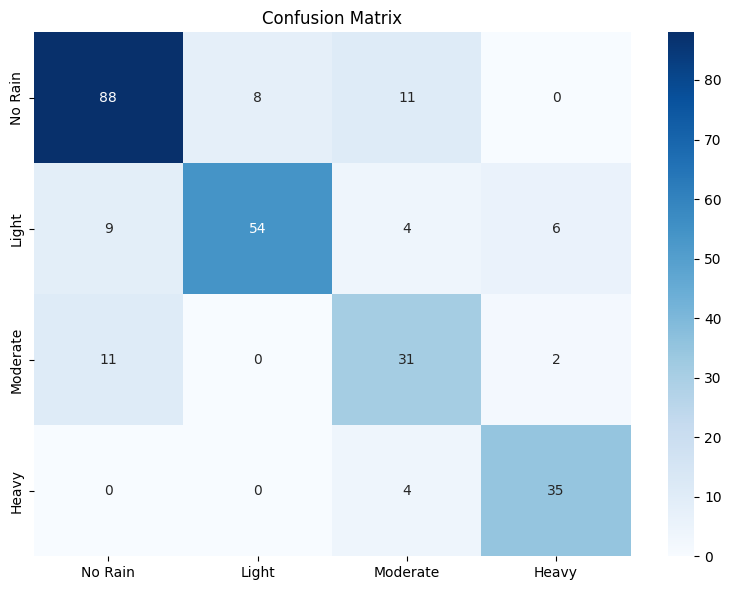

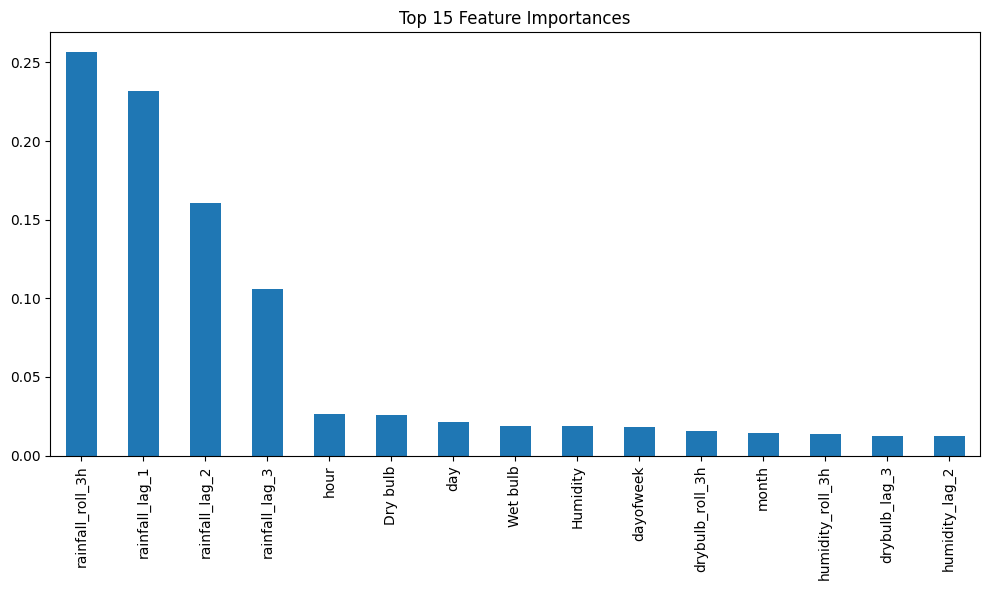

In [ ]:
# Features (excluding target, identifiers, and raw datetime)
feature_cols = [
    'Dry bulb', 'Wet bulb', 'Humidity', 'Wind speed',
    'dayofweek', 'hour', 'month','day',
    'rainfall_lag_1', 'rainfall_lag_2', 'rainfall_lag_3',
    'humidity_lag_1', 'humidity_lag_2', 'humidity_lag_3',
    'drybulb_lag_1', 'drybulb_lag_2', 'drybulb_lag_3',
    'rainfall_roll_3h', 'humidity_roll_3h', 'drybulb_roll_3h'
]


X_train = train[feature_cols]
y_train = train['rain_category']
X_test = test[feature_cols]
y_test = test['rain_category']

# Train Random Forest classifier
clsf_rf = RandomForestClassifier(n_estimators=200, max_depth=15, 
                           random_state=42, class_weight='balanced',
                           n_jobs=-1)
clsf_rf.fit(X_train, y_train)

# Predict
clsf_rf_y_pred = clsf_rf.predict(X_test)


# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, clsf_rf_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain', 'Light', 'Moderate', 'Heavy'],
            yticklabels=['No Rain', 'Light', 'Moderate', 'Heavy'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature Importance
importances = pd.Series(clsf_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [ ]:
y_test_flat = y_test_cls.values
y_pred_flat = y_pred_cat

In [ ]:
# ------------------------------
# 5. Detailed Comparison
# ------------------------------
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Quadratic Weighted Kappa'],
    'Classifier': [
        accuracy_score(y_test, clsf_rf_y_pred),
        cohen_kappa_score(y_test, clsf_rf_y_pred, weights='quadratic')
    ],
    'Regression+Map': [
        accuracy_score(y_test_flat, y_pred_flat),
        cohen_kappa_score(y_test_flat, y_pred_flat, weights='quadratic')
    ]
})

print(comparison.to_string(index=False))

# Determine winner 
# we used QWK as primary metric here because it accounts for the ordinal nature of the categories and 
# penalizes larger misclassifications more heavily, 
# which is important in our context where misclassifying 'Heavy' as 'No Rain' is worse than misclassifying 'Heavy' as 'Moderate'.

qwk_diff = comparison.loc[1, 'Regression+Map'] - comparison.loc[1, 'Classifier']
winner = 'Regression+Map' if qwk_diff > 0 else 'Classifier'
print(f"\n ⨀ Winner (based on QWK): {winner} (diff = {abs(qwk_diff):.4f})")



COMPARISON SUMMARY
                  Metric  Classifier  Regression+Map
                Accuracy    0.790875        0.711027
Quadratic Weighted Kappa    0.780690        0.802226

🏆 Winner (based on QWK): Regression+Map (diff = 0.0215)


In [ ]:

# ------------------------------
# Save Model and Scaler
# ------------------------------
weather_dir = os.path.join(MODEL_DIR[0], "weather","v0")
os.makedirs(weather_dir, exist_ok=True)

# Save the regressor and scaler
joblib.dump(rf_reg, os.path.join(weather_dir, "rf_regressor.pkl"))
joblib.dump(scaler, os.path.join(weather_dir, "scaler.pkl"))


['E:\\yr3\\year_3_ai_ml\\year_3_ai_ml\\dstse\\src\\models\\weather\\v0\\scaler.pkl']

In [ ]:

# Load (transfer or compute) thresholds from our ealier EDA we made with rain data
light_threshold = 1.40   # 33rd percentile of positive rainfall
moderate_threshold = 10.30  # 66th percentile

thresholds = {
    'light': light_threshold,
    'moderate': moderate_threshold
}

# Save thresholds for later use
with open(os.path.join(weather_dir, "rainfall_thresholds.pkl"), 'wb') as f:
    pickle.dump(thresholds, f)

# trained regressor and scaler
weather_reg = joblib.load(os.path.join(weather_dir, "rf_regressor.pkl"))
weather_scaler = joblib.load(os.path.join(weather_dir, "scaler.pkl"))

# Feature columns used in training 
weather_feature_cols = [
    'Dry bulb', 'Wet bulb', 'Humidity', 'Wind speed',
    'dayofweek', 'hour', 'month','day',
    'rainfall_lag_1', 'rainfall_lag_2', 'rainfall_lag_3',
    'humidity_lag_1', 'humidity_lag_2', 'humidity_lag_3',
    'drybulb_lag_1', 'drybulb_lag_2', 'drybulb_lag_3',
    'rainfall_roll_3h', 'humidity_roll_3h', 'drybulb_roll_3h'
]

# Save feature columns
with open(os.path.join(weather_dir, "feature_columns.json"), 'w') as f:
    json.dump(weather_feature_cols, f)

# Metadata for the weather model
weather_metadata = {
    'model_type': winner,
    'num_categories': 4,   # rainfall categories (No Rain, Light, Moderate, Heavy)
    'categories': ['No Rain', 'Light', 'Moderate', 'Heavy'],
    'thresholds': thresholds,
    'feature_columns': weather_feature_cols,
    'saved_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'description': 'Random Forest regressor predicting log rainfall, mapped to categories'
}

with open(os.path.join(weather_dir, "metadata.json"), 'w') as f:
    json.dump(weather_metadata, f, indent=2)

print(" ✓ Weather model saved successfully.")

✅ Weather model saved successfully.


#### The weather prediction function, predict_weather_bn() to test the models and output to be fed into Bayesian Network for intermediate prediction.

In [ ]:
def predict_weather_bn(target_datetime, history_df, current_obs):
    """
    Predict weather category for Bayesian Network.

    Parameters:
    - target_datetime: datetime for which to predict
    - history_df: DataFrame with columns datetime, Dry bulb, Wet bulb, Humidity, Wind speed, Total Rainfall
                  containing at least the last 3 hours before target_datetime
    - current_obs: dict with current values: 'Dry bulb', 'Wet bulb', 'Humidity', 'Wind speed'
    Returns:
    - bn_category: 'Good', 'Moderate', 'Bad'
    - confidence: float 0-1
    - rainfall_mm: float
    """
    # Load saved artifacts
    import pandas as pd
    import numpy as np
    import os
    import pickle
    import json
    import joblib
    
    

    with open(os.path.join(weather_dir, "feature_columns.json"), 'r') as f:
        feature_cols = json.load(f)
    reg = joblib.load(os.path.join(weather_dir, "rf_regressor.pkl"))
    scaler = joblib.load(os.path.join(weather_dir, "scaler.pkl"))
   
    # Combine history and current
    history_df = history_df.sort_values('datetime').copy()
    current_row = pd.DataFrame({
        'datetime': [target_datetime],
        'Dry bulb': [current_obs['Dry bulb']],
        'Wet bulb': [current_obs['Wet bulb']],
        'Humidity': [current_obs['Humidity']],
        'Wind speed': [current_obs['Wind speed']],
        'Total Rainfall': [0]   # placeholder for lags
    })
    full = pd.concat([history_df, current_row], ignore_index=True).set_index('datetime')
    full = full.sort_index()

    
    # Compute lag features (1,2,3) for rainfall, humidity, dry bulb
    for lag in [1, 2, 3]:
        full[f'rainfall_lag_{lag}'] = full['Total Rainfall'].shift(lag)
        full[f'humidity_lag_{lag}'] = full['Humidity'].shift(lag)
        full[f'drybulb_lag_{lag}'] = full['Dry bulb'].shift(lag)

    # Compute rolling means over 3 hours
    full['rainfall_roll_3h'] = full['Total Rainfall'].rolling(window=3, min_periods=1).mean()
    full['humidity_roll_3h'] = full['Humidity'].rolling(window=3, min_periods=1).mean()
    full['drybulb_roll_3h'] = full['Dry bulb'].rolling(window=3, min_periods=1).mean()

    
    # Add the basic time features (raw hour, month, day, dayofweek) for the target row
    row = full.loc[[target_datetime]].copy()
    row['dayofweek'] = target_datetime.weekday()
    row['hour'] = target_datetime.hour
    row['month'] = target_datetime.month
    row['day'] = target_datetime.day
    
    # checking that we have all required features (drop rows with NaN, though we expect all computed)
    row = row.dropna(axis=1, how='any')
    
    
    X = row[feature_cols]
    
    # Scale
    X_scaled = scaler.transform(X)
    
    # Predict log rainfall
    log_rain = reg.predict(X_scaled)[0]
    rain_mm = np.expm1(log_rain)

    # Map to 4 categories (using thresholds saved earlier)
    with open(os.path.join(weather_dir, "rainfall_thresholds.pkl"), 'rb') as f:
        thresholds = pickle.load(f)
    if rain_mm == 0:
        category_4 = 'No Rain'
    elif rain_mm <= thresholds['light']:
        category_4 = 'Light'
    elif rain_mm <= thresholds['moderate']:
        category_4 = 'Moderate'
    else:
        category_4 = 'Heavy'

    # Map to BN 3 categories
    if category_4 in ['No Rain', 'Light']:
        bn_category = 'Good'
    elif category_4 == 'Moderate':
        bn_category = 'Moderate'
    else:
        bn_category = 'Bad'

    # Confidence 
    if bn_category == 'Good':
        confidence = 1 - min(rain_mm / thresholds['light'], 1.0)
    elif bn_category == 'Moderate':
        band = thresholds['moderate'] - thresholds['light']
        mid = (thresholds['light'] + thresholds['moderate']) / 2
        confidence = 1 - (2 * abs(rain_mm - mid) / band)
    else:
        max_heavy = thresholds['moderate'] * 2
        confidence = min((rain_mm - thresholds['moderate']) / (max_heavy - thresholds['moderate']), 1.0)
    confidence = max(0.0, min(1.0, confidence))

    return bn_category, confidence, rain_mm

In [ ]:
# Generate a sample history (last 3 hours before 12:00)
past = pd.DataFrame({
    'datetime': pd.date_range(start='2023-03-24 08:00:00', periods=3, freq='h'), 
    'Dry bulb': [24, 24.5, 25],
    'Wet bulb': [19, 19.5, 20],
    'Humidity': [80, 78, 75],
    'Wind speed': [4, 4.5, 5],
    'Total Rainfall': [0, 0, 0]
})
current = {
    'Dry bulb': 26,
    'Wet bulb': 21,
    'Humidity': 72,
    'Wind speed': 6
}
target = pd.Timestamp('2023-03-24 10:30:00')
cat, conf, rain = predict_weather_bn(target, past, current)
print(cat, conf, rain)

Good 1.0 0.0


# TRAFFIC
### classifier and regressor for traffic congestion prediction

In [ ]:

# Load processed traffic data (road-level with features)
df = pd.read_csv(INPUT_FILE['other'][2], encoding='utf-8')


In [ ]:
df.head()

,road,datetime,month,hour,day_of_week,is_weekend,is_rush_hour,estimated_vehicle_count,congestion
0,Bombo Road,2023-08-17 00:00:00,8,0,3,0,0,15,Low
1,Bombo Road,2023-08-17 00:15:00,8,0,3,0,0,15,Low
2,Bombo Road,2023-08-17 00:30:00,8,0,3,0,0,15,Low
3,Bombo Road,2023-08-17 00:45:00,8,0,3,0,0,15,Low
4,Bombo Road,2023-08-17 01:00:00,8,1,3,0,0,15,Low


In [ ]:
clsf_reg=df.copy()

In [ ]:
# the the five classes we removed and shifted to the three classes of Low, Normal, Very high
# ------------------------------
# Configuration and Helper Functions
# ------------------------------
# def count_to_congestion(count, low_th, medium_th, normal_th, high_th, very_high_th):
#     """
#     Convert vehicle count to congestion level with 5 ordinal categories.
#     Uses percentile-based thresholds.
#     """
#     if count <= low_th:
#         return 'Low'
#     elif count <= medium_th:
#         return 'Medium'
#     elif count <= normal_th:
#         return 'Normal'
#     elif count <= high_th:
#         return 'High'
#     else:
#         return 'Very high'

def count_to_congestion(count, low_th, normal_th):
    """
    Convert vehicle count to congestion level with 5 ordinal categories.
    Uses percentile-based thresholds.
    """
    if count <= low_th:
        return 'Low'
    elif count <= normal_th:
        return 'Normal'
    else:
        return 'Very high'


def plot_confusion_matrix(y_true, y_pred, classes, title, ax, cmap='Blues'):
    """Helper to plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, 
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

def temporal_train_test_split(df, test_size=0.2):
    """Split data chronologically by date"""
    dates = df['datetime'].dt.date.unique()
    dates = np.sort(dates)
    split_idx = int((1 - test_size) * len(dates))
    train_dates = dates[:split_idx]
    test_dates = dates[split_idx:]
    
    train_mask = df['datetime'].dt.date.isin(train_dates)
    test_mask = df['datetime'].dt.date.isin(test_dates)
    
    return train_mask, test_mask, train_dates, test_dates


In [ ]:
# ------------------------------
# Load and prepare data
# ------------------------------


clsf_reg['datetime'] = pd.to_datetime(clsf_reg['datetime'])

# Sort chronologically
clsf_reg = clsf_reg.sort_values('datetime').reset_index(drop=True)

# Compute percentile thresholds 
# percentiles = [0.20, 0.40, 0.60, 0.80, 0.95]

percentiles = [0.20, 0.60]
# thresholds = df['estimated_vehicle_count'].quantile(percentiles).values
# low_th, medium_th, normal_th, high_th, very_high_th = thresholds
thresholds = clsf_reg['estimated_vehicle_count'].quantile(percentiles).values
low_th, normal_th = thresholds

print("="*60)
print("TRAFFIC DATA PREPARATION")
print("="*60)
print(f"Data shape: {clsf_reg.shape}")
print(f"Date range: {clsf_reg['datetime'].min()} to {clsf_reg['datetime'].max()}")
print(f"\nThresholds based on data distribution:")
print(f"20th percentile (Low/Normal): {low_th:.2f}")

print(f"60th percentile (Normal/Very High): {normal_th:.2f}")

# Check distribution
print("\nCongestion category distribution:")
print(clsf_reg['congestion'].value_counts().sort_index())

# Feature columns 
feature_cols = ['hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'month']

# Add road as feature
include_road = True  # Set to False if want to exclude road
if include_road and 'road' in clsf_reg.columns:
    # Create dummy variables for road (ONE-HOT ENCODING)
    road_dummies = pd.get_dummies(clsf_reg['road'], prefix='road', drop_first=False)
    clsf_reg = pd.concat([clsf_reg, road_dummies], axis=1)
    
    # Get the dummy column names
    road_feature_cols = road_dummies.columns.tolist()
    
    # EXTEND feature_cols with dummy columns ONLY (NOT the original 'road')
    feature_cols.extend(road_feature_cols)
    
    print(f"\nAdded {len(road_feature_cols)} road features:")
    print(road_feature_cols)
    
    # Drop the original 'road' column to avoid confusion
    clsf_reg = clsf_reg.drop('road', axis=1)

# Verify that all features are numeric
print("\nFeature data types:")
print(clsf_reg[feature_cols].dtypes)


# Encode target for classifier
le = LabelEncoder()
clsf_reg['congestion_encoded'] = le.fit_transform(clsf_reg['congestion'])
congestion_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nCongestion class mapping:", congestion_mapping)


TRAFFIC DATA PREPARATION
Data shape: (40320, 9)
Date range: 2023-08-17 00:00:00 to 2023-12-20 23:45:00

Thresholds based on data distribution:
20th percentile (Low/Normal): 15.00
60th percentile (Normal/Very High): 30.00

Congestion category distribution:
congestion
Low           8210
Normal       19653
Very high    12457
Name: count, dtype: int64

Added 4 road features:
['road_Bombo Road', 'road_Northern Bypass', 'road_Sir Apolo Road', 'road_University Road']

Feature data types:
hour                    int64
day_of_week             int64
is_weekend              int64
is_rush_hour            int64
month                   int64
road_Bombo Road          bool
road_Northern Bypass     bool
road_Sir Apolo Road      bool
road_University Road     bool
dtype: object

Congestion class mapping: {'Low': np.int64(0), 'Normal': np.int64(1), 'Very high': np.int64(2)}


In [ ]:
# ------------------------------
# Temporal train/test split
# ------------------------------
train_mask, test_mask, train_dates, test_dates = temporal_train_test_split(clsf_reg, test_size=0.2)

X_train = clsf_reg.loc[train_mask, feature_cols]
X_test = clsf_reg.loc[test_mask, feature_cols]

# Targets for both approaches
y_train_class = clsf_reg.loc[train_mask, 'congestion_encoded']
y_test_class = clsf_reg.loc[test_mask, 'congestion_encoded']
y_train_reg = clsf_reg.loc[train_mask, 'estimated_vehicle_count']
y_test_reg = clsf_reg.loc[test_mask, 'estimated_vehicle_count']
y_test_category = clsf_reg.loc[test_mask, 'congestion']

print(f"\nTrain size: {len(X_train)} samples ({len(train_dates)} days)")
print(f"Test size: {len(X_test)} samples ({len(test_dates)} days)")
print(f"\nClass distribution in train:")
print(clsf_reg.loc[train_mask, 'congestion'].value_counts().sort_index())

# ------------------------------
# Approach 1: Direct Classification
# ------------------------------
print("\n" + "="*60)
print("APPROACH 1: DIRECT CLASSIFICATION")
print("="*60)

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train_class)
y_pred_class = clf.predict(X_test)

# Classification metrics
print(f"\nAccuracy: {accuracy_score(y_test_class, y_pred_class):.4f}")
print(f"Quadratic Weighted Kappa: {cohen_kappa_score(y_test_class, y_pred_class, weights='quadratic'):.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test_class, 
    y_pred_class, 
    target_names=le.classes_,
    digits=4
))

# Feature importance for classifier
clf_importance = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\n\nClassifier Top 10 Feature Importances:")
print(clf_importance.head(10))




Train size: 32256 samples (84 days)
Test size: 8064 samples (21 days)

Class distribution in train:
congestion
Low           6401
Normal       15552
Very high    10303
Name: count, dtype: int64

APPROACH 1: DIRECT CLASSIFICATION

Accuracy: 0.7677
Quadratic Weighted Kappa: 0.7886

Classification Report:
              precision    recall  f1-score   support

         Low     0.8469    0.8839    0.8650      1809
      Normal     0.8636    0.6452    0.7386      4101
   Very high     0.6253    0.9034    0.7391      2154

    accuracy                         0.7677      8064
   macro avg     0.7786    0.8109    0.7809      8064
weighted avg     0.7962    0.7677    0.7671      8064



Classifier Top 10 Feature Importances:
hour                    0.482629
road_University Road    0.120281
road_Northern Bypass    0.106808
day_of_week             0.081091
is_rush_hour            0.075821
month                   0.048918
is_weekend              0.036501
road_Bombo Road         0.025722
road_Sir 


APPROACH 2: REGRESSION + MAPPING

--- Regression Performance ---
RMSE: 7.2140
MAE: 5.3564
R²: 0.6294

--- Classification Performance after Mapping ---
Accuracy: 0.7144
Quadratic Weighted Kappa: 0.7181

Classification Report:
              precision    recall  f1-score   support

         Low     0.9353    0.5998    0.7309      1809
      Normal     0.7443    0.6679    0.7040      4101
   Very high     0.6008    0.8993    0.7203      2154

    accuracy                         0.7144      8064
   macro avg     0.7601    0.7223    0.7184      8064
weighted avg     0.7488    0.7144    0.7144      8064


Regressor Top 10 Feature Importances:
road_Northern Bypass    0.268796
is_rush_hour            0.256986
hour                    0.239051
road_University Road    0.101870
day_of_week             0.060299
month                   0.036577
is_weekend              0.027467
road_Sir Apolo Road     0.004490
road_Bombo Road         0.004465
dtype: float64

COMPARISON SUMMARY
                  Metr

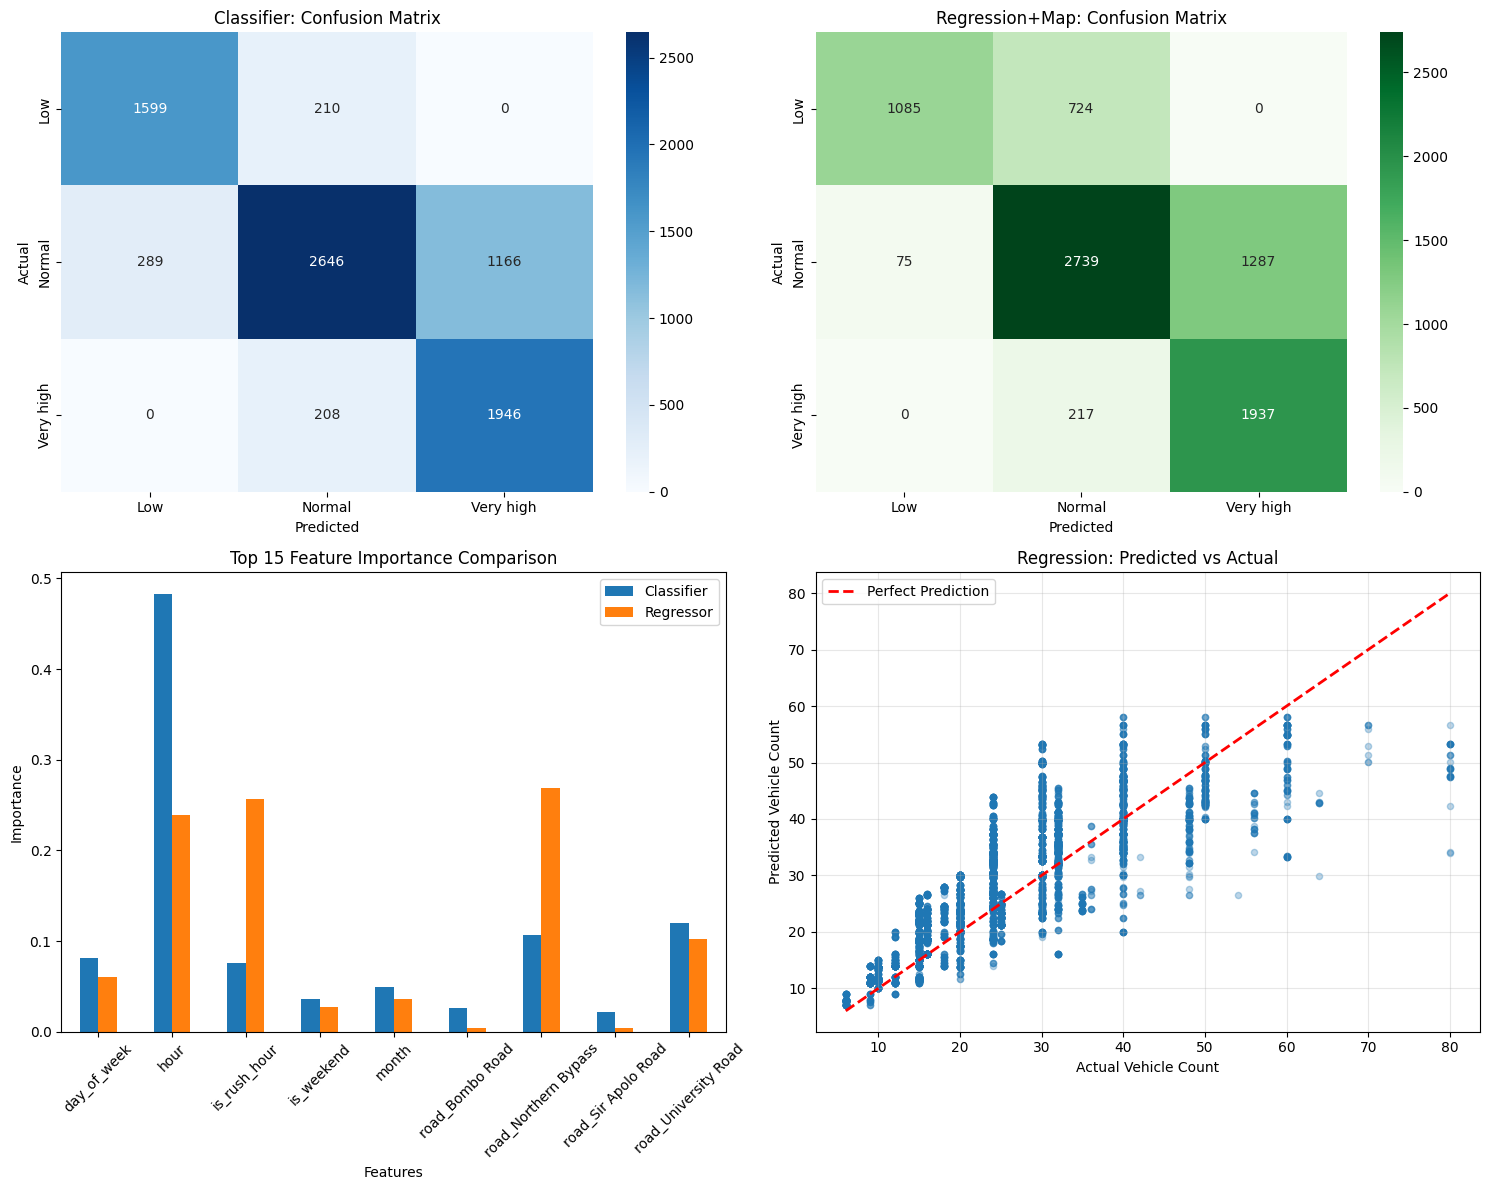


ERROR ANALYSIS

Misclassification rate (regression+map): 28.56%

Sample of misclassified samples (first 10):
          Actual  Predicted  Actual_Count  Predicted_Count      Error
32413     Normal  Very high            30        41.142996 -11.142996
32418     Normal  Very high            24        31.385784  -7.385784
32429     Normal  Very high            24        31.385784  -7.385784
32434     Normal  Very high            24        33.547300  -9.547300
32435  Very high     Normal            32        24.028745   7.971255
32436  Very high     Normal            32        24.028745   7.971255
32438     Normal  Very high            24        33.547300  -9.547300
32440     Normal  Very high            24        33.547300  -9.547300
32443  Very high     Normal            32        24.028745   7.971255
32445     Normal  Very high            24        33.547300  -9.547300

Top misclassification patterns:
      Actual  Predicted  count
2     Normal  Very high   1287
0        Low     Normal  

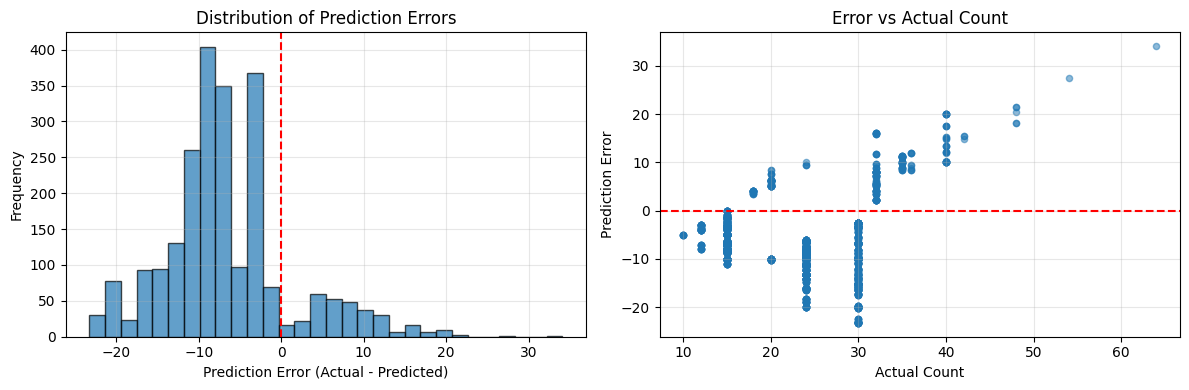

In [ ]:
# ------------------------------
# Approach 2: Regression + Mapping
# ------------------------------
print("\n" + "="*60)
print("APPROACH 2: REGRESSION + MAPPING")
print("="*60)

reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

reg.fit(X_train, y_train_reg)
y_pred_reg = reg.predict(X_test)

# Regression metrics
print("\n--- Regression Performance ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.4f}")
print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")
print(f"R²: {r2_score(y_test_reg, y_pred_reg):.4f}")

# Map predictions to categories (Vectorized mapping)
y_pred_reg_category = np.array([
    # count_to_congestion(x, low_th, , normal_th, high_th, very_high_th) 
    count_to_congestion(x, low_th, normal_th)
    for x in y_pred_reg
])

# Encode for metric calculation
y_pred_reg_encoded = le.transform(y_pred_reg_category)

# Classification metrics for regression+map
print("\n--- Classification Performance after Mapping ---")
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_reg_encoded):.4f}")
print(f"Quadratic Weighted Kappa: {cohen_kappa_score(y_test_class, y_pred_reg_encoded, weights='quadratic'):.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test_class, 
    y_pred_reg_encoded, 
    target_names=le.classes_,
    digits=4
))

# Feature importance for regressor
reg_importance = pd.Series(reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nRegressor Top 10 Feature Importances:")
print(reg_importance.head(10))



# ------------------------------
# Detailed Comparison
# ------------------------------
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Quadratic Weighted Kappa'],
    'Classifier': [
        accuracy_score(y_test_class, y_pred_class),
        cohen_kappa_score(y_test_class, y_pred_class, weights='quadratic')
    ],
    'Regression+Map': [
        accuracy_score(y_test_class, y_pred_reg_encoded),
        cohen_kappa_score(y_test_class, y_pred_reg_encoded, weights='quadratic')
    ]
})

print(comparison.to_string(index=False))

# Determine winner (we Used QWK as primary metric)
qwk_diff = comparison.loc[1, 'Regression+Map'] - comparison.loc[1, 'Classifier']
winner = 'Regression+Map' if qwk_diff > 0 else 'Classifier'
print(f"\n ⨀ Winner (based on QWK): {winner} (diff = {abs(qwk_diff):.4f})")



# ------------------------------
# Visual Comparison
# ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Confusion Matrix - Classifier
plot_confusion_matrix(
    y_test_class, y_pred_class, le.classes_, 
    'Classifier: Confusion Matrix', axes[0,0], 'Blues'
)

# Confusion Matrix - Regression+Map
plot_confusion_matrix(
    y_test_class, y_pred_reg_encoded, le.classes_,
    'Regression+Map: Confusion Matrix', axes[0,1], 'Greens'
)

# Feature Importance Comparison
importance_df = pd.DataFrame({
    'Classifier': clf_importance,
    'Regressor': reg_importance
}).fillna(0).sort_index()

importance_df.head(15).plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Top 15 Feature Importance Comparison')
axes[1,0].set_xlabel('Features')
axes[1,0].set_ylabel('Importance')
axes[1,0].legend()
axes[1,0].tick_params(axis='x', rotation=45)

# Predicted vs Actual (Regression scatter)
axes[1,1].scatter(y_test_reg, y_pred_reg, alpha=0.3, s=20)
axes[1,1].plot([y_test_reg.min(), y_test_reg.max()], 
               [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1,1].set_xlabel('Actual Vehicle Count')
axes[1,1].set_ylabel('Predicted Vehicle Count')
axes[1,1].set_title('Regression: Predicted vs Actual')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

plt.tight_layout()
plt.show()



# ------------------------------
# Error Analysis
# ------------------------------
print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)


misclassified = y_test_class != y_pred_reg_encoded
misclass_rate = misclassified.mean() * 100
print(f"\nMisclassification rate (regression+map): {misclass_rate:.2f}%")

if misclassified.any():
    misclass_df = pd.DataFrame({
        'Actual': le.inverse_transform(y_test_class[misclassified]),
        'Predicted': le.inverse_transform(y_pred_reg_encoded[misclassified]),
        'Actual_Count': y_test_reg[misclassified],
        'Predicted_Count': y_pred_reg[misclassified],
        'Error': y_test_reg[misclassified] - y_pred_reg[misclassified]
    })
    
    print("\nSample of misclassified samples (first 10):")
    print(misclass_df.head(10))
    
    # Count misclassifications by type
    misclass_summary = misclass_df.groupby(['Actual', 'Predicted']).size().reset_index(name='count')
    misclass_summary = misclass_summary.sort_values('count', ascending=False)
    print("\nTop misclassification patterns:")
    print(misclass_summary.head(10))
    
    # Plot error distribution
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Error histogram
    ax[0].hist(misclass_df['Error'], bins=30, edgecolor='black', alpha=0.7)
    ax[0].axvline(x=0, color='red', linestyle='--')
    ax[0].set_xlabel('Prediction Error (Actual - Predicted)')
    ax[0].set_ylabel('Frequency')
    ax[0].set_title('Distribution of Prediction Errors')
    ax[0].grid(True, alpha=0.3)
    
    # Error by actual count
    ax[1].scatter(misclass_df['Actual_Count'], misclass_df['Error'], alpha=0.5, s=20)
    ax[1].axhline(y=0, color='red', linestyle='--')
    ax[1].set_xlabel('Actual Count')
    ax[1].set_ylabel('Prediction Error')
    ax[1].set_title('Error vs Actual Count')
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    



In [ ]:
# ------------------------------
# Save the best model
# ------------------------------

print("\n" + "="*60)
print("SAVING PRODUCTION MODEL")
print("="*60)
print(f"Base model directory: {MODEL_DIR[0]}")

# Create traffic subdirectory
traffic_dir = os.path.join(MODEL_DIR[0], "traffic")
os.makedirs(traffic_dir, exist_ok=True)
print(f"Traffic model directory: {traffic_dir}")

# Define thresholds for 3 categories
thresholds_dict = {
    'low': float(low_th),        # 20th percentile
    'normal': float(normal_th),   # 60th percentile
    # Note: 'very_high' is anything above normal_th
}

print(f"\nThresholds (3 categories):")
print(f"  Low/Normal boundary: {thresholds_dict['low']:.2f}")
print(f"  Normal/Very High boundary: {thresholds_dict['normal']:.2f}")




SAVING PRODUCTION MODEL
Base model directory: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models
Traffic model directory: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\traffic

Thresholds (3 categories):
  Low/Normal boundary: 15.00
  Normal/Very High boundary: 30.00


In [ ]:
metadata_file=None
# Save based on winner
if winner == 'Classifier':
    print("\n ✓ Saving Classifier as production model")
    
    # Create classifier subdirectory
    classifier_dir = os.path.join(traffic_dir, "clsf","v0")
    os.makedirs(classifier_dir, exist_ok=True)
    metadata_file=classifier_dir
    # Save model and encoder
    model_path = os.path.join(classifier_dir, "classifier.pkl")
    encoder_path = os.path.join(classifier_dir, "label_encoder.pkl")
    
    joblib.dump(clf, model_path)
    joblib.dump(le, encoder_path)
    
    print(f"  - Model saved to: {model_path}")
    print(f"  - Encoder saved to: {encoder_path}")
    
    # Save metadata for 3 categories
    metadata = {
        'model_type': 'classifier',
        'num_categories': 3,
        'categories': ['Low', 'Normal', 'Very High'],
        'thresholds': thresholds_dict,
        'feature_columns': feature_cols,
        'congestion_mapping': {str(k): int(v) for k, v in congestion_mapping.items()},
        'accuracy': float(comparison.loc[0, 'Classifier']),
        'qwk': float(comparison.loc[1, 'Classifier']),
        'saved_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'data_range': {
            'start': str(df['datetime'].min()),
            'end': str(df['datetime'].max())
        }
    }
    
else:  # Regressor+Map
    print("\n ✓ Saving Regressor+Map as production model")
    
    # Create regressor subdirectory
    regressor_dir = os.path.join(traffic_dir, "reg")
    os.makedirs(regressor_dir, exist_ok=True)
    metadata_file=regressor_dir
    
    # Save model and encoder
    model_path = os.path.join(regressor_dir, "regressor.pkl")
    encoder_path = os.path.join(regressor_dir, "label_encoder.pkl")
    
    joblib.dump(reg, model_path)
    joblib.dump(le, encoder_path)
    
    print(f"  - Model saved to: {model_path}")
    print(f"  - Encoder saved to: {encoder_path}")
    
    # Save thresholds for 3 categories
    thresholds_path = os.path.join(regressor_dir, "count_to_category_thresholds.pkl")
    with open(thresholds_path, 'wb') as f:
        pickle.dump(thresholds_dict, f)
    
    print(f"  - Thresholds saved to: {thresholds_path}")
    
    # Save metadata for 3 categories
    metadata = {
        'model_type': 'regressor',
        'num_categories': 3,
        'categories': ['Low', 'Normal', 'Very High'],
        'thresholds': thresholds_dict,
        'feature_columns': feature_cols,
        'congestion_mapping': {str(k): int(v) for k, v in congestion_mapping.items()},
        'accuracy': float(comparison.loc[0, 'Regression+Map']),
        'qwk': float(comparison.loc[1, 'Regression+Map']),
        'saved_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'data_range': {
            'start': str(df['datetime'].min()),
            'end': str(df['datetime'].max())
        }
    }




✅ Saving Classifier as production model


  - Model saved to: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\traffic\clsf\v0\classifier.pkl
  - Encoder saved to: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\traffic\clsf\v0\label_encoder.pkl


In [ ]:
# Save metadata in the traffic directory (both pickle and JSON)
metadata_pkl_path = os.path.join(metadata_file, "metadata.pkl")
with open(metadata_pkl_path, 'wb') as f:
    pickle.dump(metadata, f)

metadata_json_path = os.path.join(metadata_file, "metadata.json")
with open(metadata_json_path, 'w') as f:
    # Convert any numpy types to Python native types
    json_metadata = {}
    for k, v in metadata.items():
        if isinstance(v, dict):
            json_metadata[k] = {kk: float(vv) if hasattr(vv, 'item') else vv 
                               for kk, vv in v.items()}
        elif hasattr(v, 'item'):  # numpy type
            json_metadata[k] = float(v)
        else:
            json_metadata[k] = v
    json.dump(json_metadata, f, indent=2)

print(f"\n  - Metadata saved to: {metadata_pkl_path}")
print(f"  - Metadata JSON saved to: {metadata_json_path}")

# Create a README  file summarizing the model, thresholds, performance, and features
# such that anyone can quickly understand the model without needing to load the metadata or code
# we did this for any other team memeber who might want to use the model without diving into the code or metadata details
readme_path = os.path.join(traffic_dir, "README.txt")
with open(readme_path, 'w') as f:
    f.write("TRAFFIC PREDICTION MODEL\n")
    f.write("="*50 + "\n\n")
    f.write(f"Model Type: {metadata['model_type']}\n")
    f.write(f"Number of Categories: {metadata['num_categories']}\n")
    f.write(f"Categories: {metadata['categories']}\n")
    f.write(f"Saved Date: {metadata['saved_date']}\n\n")
    f.write(f"Thresholds:\n")
    f.write(f"  - Low/Normal: {thresholds_dict['low']:.2f}\n")
    f.write(f"  - Normal/Very High: {thresholds_dict['normal']:.2f}\n\n")
    f.write(f"Performance:\n")
    f.write(f"  - Accuracy: {metadata['accuracy']:.4f}\n")
    f.write(f"  - QWK: {metadata['qwk']:.4f}\n\n")
    f.write(f"Feature Columns:\n")
    for col in metadata['feature_columns']:
        f.write(f"  - {col}\n")

print(f"  - README saved to: {readme_path}")
print(f"\n ✓ Model saved successfully in: {traffic_dir}")




  - Metadata saved to: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\traffic\clsf\v0\metadata.pkl
  - Metadata JSON saved to: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\traffic\clsf\v0\metadata.json
  - README saved to: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\traffic\README.txt

✅ Model saved successfully in: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\traffic


In [ ]:
# ------------------------------
# Prediction Function for 3 Categories
# ------------------------------
def predict_traffic(datetime_value, road=None, model_path=None):
    """
    Predict traffic congestion for a given datetime (3 categories: Low, Normal, Very High).
    X_scaled shape
    Parameters:
    - datetime_value: pandas Timestamp or datetime string
    - road: road name (e.g., 'Bombo Road', 'Northern Bypass')
    - model_path: path to traffic model directory (if None, uses default)
    X
    Returns:
    - congestion: predicted congestion category ('Low', 'Normal', 'Very High')
    - confidence: confidence score (0-1)
    """
    import pandas as pd
    import numpy as np
    import joblib
    import pickle
    import json
    import os

    
    # Use default path if not provided
    if model_path is None:
        model_path = os.path.join(MODEL_DIR[0], "traffic")
    
    # Load metadata
    with open(os.path.join(model_path, "clsf", "v0", "metadata.json"), 'r') as f:
        metadata = json.load(f)
    
    model_type = metadata['model_type']
    feature_cols = metadata['feature_columns']
    thresholds = metadata['thresholds']
    
    # Convert input to datetime if string
    if isinstance(datetime_value, str):
        datetime_value = pd.to_datetime(datetime_value)
    
    # Create base features
    features = {
        'hour': datetime_value.hour,
        'day_of_week': datetime_value.dayofweek,
        'is_weekend': 1 if datetime_value.dayofweek >= 5 else 0,
        'is_rush_hour': 1 if (7 <= datetime_value.hour <= 9) or (16 <= datetime_value.hour <= 19) else 0,
        'month': datetime_value.month
    }
    # Add road features
    road_cols = [col for col in feature_cols if col.startswith('road_')]
    if road_cols and road:
        # Set all road dummies to 0 first
        for col in road_cols:
            features[col] = 0
        # Set the specified road to 1
        road_dummy = f"road_{road}"
        if road_dummy in features:
            features[road_dummy] = 1
    
    # Create DataFrame with correct column order
    X_pred = pd.DataFrame([features])[feature_cols]
    
    if model_type == 'classifier':
        # Load classifier
        model = joblib.load(os.path.join(model_path, "clsf","v0", "classifier.pkl"))
        encoder = joblib.load(os.path.join(model_path, "clsf", "v0", "label_encoder.pkl"))
        
        # Predict
        pred_encoded = model.predict(X_pred)[0]
        probabilities = model.predict_proba(X_pred)[0]
        
        congestion = encoder.inverse_transform([pred_encoded])[0]
        confidence = float(probabilities[pred_encoded])
        
        return congestion, confidence
    
    else:  # regressor
        # Load regressor
        model = joblib.load(os.path.join(model_path, "reg", "regressor.pkl"))
        
        # Predict count
        pred_count = model.predict(X_pred)[0]
        
        # Map to 3 categories using thresholds
        def count_to_congestion_pred(count):
            if count <= thresholds['low']:
                return 'Low'
            elif count <= thresholds['normal']:
                return 'Normal'
            else:
                return 'Very High'
        
        congestion = count_to_congestion_pred(pred_count)
        
        # Calculate confidence based on distance to thresholds
        if congestion == 'Low':
            # Distance from low threshold (lower is better)
            confidence = 1 - (pred_count / thresholds['low'])
        elif congestion == 'Normal':
            # In the middle band - confidence based on distance to both thresholds
            band_width = thresholds['normal'] - thresholds['low']
            mid_point = (thresholds['low'] + thresholds['normal']) / 2
            distance_to_mid = abs(pred_count - mid_point)
            confidence = 1 - (2 * distance_to_mid / band_width)
        else:  # 'Very High'
            # Above normal threshold
            # Use a reference point (normal threshold + typical range)
            typical_range = thresholds['normal'] * 0.5
            distance_from_threshold = pred_count - thresholds['normal']
            confidence = min(1, distance_from_threshold / typical_range)
        
        # Ensure confidence is between 0 and 1
        confidence = max(0, min(1, confidence))
        
        return congestion, float(confidence)



In [ ]:
# ------------------------------
# Test the prediction function
# ------------------------------
print("\n" + "="*60)
print("TESTING PREDICTION FUNCTION (3 Categories)")
print("="*60)

# Test with a few different times
test_times = [
    '2026-09-05 08:30:00',  # Tuesday morning rush hour
    '2026-09-05 14:00:00',  # Tuesday afternoon
    '2026-09-09 10:00:00',  # Saturday
    '2026-09-05 23:00:00',  # Late night
]


print(f"\nThresholds: Low < {thresholds_dict['low']:.1f} | "
      f"Normal {thresholds_dict['low']:.1f}-{thresholds_dict['normal']:.1f} | "
      f"Very High > {thresholds_dict['normal']:.1f}")



for test_time in test_times:
    try:
        test_time = pd.Timestamp(test_time)
        congestion, confidence = predict_traffic(test_time, 'Bombo Road')
        print(f"\n{test_time} (Bombo Road): {congestion} (confidence: {confidence:.2f})")
    except Exception as e:
        print(f"\n{test_time}: Error - {e}")

print("\n" + "="*60)
print(" ✓ TRAFFIC MODEL PIPELINE COMPLETE (3 Categories)")
print("="*60)


TESTING PREDICTION FUNCTION (3 Categories)

Thresholds: Low < 15.0 | Normal 15.0-30.0 | Very High > 30.0

2023-09-05 08:30:00 (Bombo Road): Normal (confidence: 0.93)

2023-09-05 14:00:00 (Bombo Road): Very high (confidence: 0.73)

2023-09-09 10:00:00 (Bombo Road): Normal (confidence: 1.00)

2023-09-05 23:00:00 (Bombo Road): Low (confidence: 0.70)

✅ TRAFFIC MODEL PIPELINE COMPLETE (3 Categories)


### NOTE: FOR TRAFFIC AND WEATHER DATA, WE TRIED LSTM FOR EACH. HOWEVER, DUE TO THE LIMITED DATA SIZE AND THE NATURE OF THE PROBLEM, LSTM DID NOT PERFORM WELL. INSTEAD, WE FOCUSED ON RANDOM FOREST MODELS WHICH WERE MORE SUITABLE FOR THIS TASK.

# BAYESSIAN NETWORK
###### A Bayesian Network is a probabilistic graphical model that represents a set of variables and their conditional dependencies using a directed acyclic graph (DAG). Each node in the graph represents a random variable, and the edges represent the probabilistic dependencies between these variables. Bayesian Networks are used for reasoning under uncertainty, allowing for inference, prediction, and decision-making based on observed evidence. They are widely applied in various fields, including machine learning, artificial intelligence, and statistics.

In [ ]:
states = {
    'Weather': ['Good', 'Moderate', 'Bad'],
    'Traffic': ['Low', 'Normal', 'Heavy'],
    'Delay': ['NoDelay', 'ShortDelay', 'LongDelay'],
    'Decision': ['Scheduled', 'Online', 'Rescheduled', 'Cancelled']
}

edges = [
    ('Weather', 'Delay'),
    ('Traffic', 'Delay'),
    ('Delay', 'Decision')
]

model = DiscreteBayesianNetwork(edges)

# Prior for Weather
cpd_weather = TabularCPD(
    variable='Weather', variable_card=3,
    values=[[0.4], [0.4], [0.2]],   # Good, Moderate, Bad
    state_names={'Weather': states['Weather']}
)

# Prior for Traffic
cpd_traffic = TabularCPD(
    variable='Traffic', variable_card=3,
    values=[[0.5], [0.3], [0.2]],   # Low, Normal, Heavy
    state_names={'Traffic': states['Traffic']}
)

# Delay CPT 
def delay_base_from_weather_traffic(weather, traffic):
    base = 0.0
    if weather == 'Bad':
        base += 0.8
    elif weather == 'Moderate':
        base += 0.4
    else:
        base += 0.1
    if traffic == 'Heavy':
        base += 0.3
    elif traffic == 'Normal':
        base += 0.1
    return min(base, 1.0)

delay_values = []
for w in states['Weather']:
    for t in states['Traffic']:
        base = delay_base_from_weather_traffic(w, t)
        no_delay = 1.0 - base
        short_delay = base * 0.7
        long_delay = base * 0.3
        delay_values.append([no_delay, short_delay, long_delay])

delay_probs = np.array(delay_values).T  # shape (3,9)

cpd_delay = TabularCPD(
    variable='Delay', variable_card=3,
    values=delay_probs,
    evidence=['Weather', 'Traffic'], evidence_card=[3, 3],
    state_names={
        'Delay': states['Delay'],
        'Weather': states['Weather'],
        'Traffic': states['Traffic']
    }
)

# Decision CPT (conditional on Delay)
# decision_probs = np.array([
#     [0.8, 0.3, 0.1],   # Scheduled
#     [0.1, 0.5, 0.4],   # Online
#     [0.1, 0.1, 0.3],   # Rescheduled
#     [0.0, 0.1, 0.2]    # Cancelled
# ])

# audited version
# Rows: Scheduled, Online, Rescheduled, Cancelled
# Columns: NoDelay, ShortDelay, LongDelay
decision_probs = np.array([
    [0.90, 0.20, 0.05],   # Scheduled (Drops hard on LongDelay)
    [0.05, 0.70, 0.85],   # Online (Rises sharply to 85% on LongDelay)
    [0.04, 0.05, 0.05],   # Rescheduled
    [0.01, 0.05, 0.05]    # Cancelled
])

cpd_decision = TabularCPD(
    variable='Decision', variable_card=4,
    values=decision_probs,
    evidence=['Delay'], evidence_card=[3],
    state_names={
        'Decision': states['Decision'],
        'Delay': states['Delay']
    }
)

# Add all CPDs
model.add_cpds(cpd_weather, cpd_traffic, cpd_delay, cpd_decision)

if model.check_model():
    print(" ✓ Model valid.")
    inference = VariableElimination(model)
else:
    print(" ✕ Model invalid.")
    exit()

# Test cases
test_cases = [
    {'Weather': 'Bad', 'Traffic': 'Heavy'},
    {'Weather': 'Good', 'Traffic': 'Low'},
    {'Weather': 'Moderate', 'Traffic': 'Normal'}
]

print("\n=== Decision Probabilities ===")
for ev in test_cases:
    result = inference.query(variables=['Decision'], evidence=ev)
    print(f"\nWeather={ev['Weather']}, Traffic={ev['Traffic']}:")
    print(result)

✅ Model valid.

=== Decision Probabilities ===

Weather=Bad, Traffic=Heavy:
+-----------------------+-----------------+
| Decision              |   phi(Decision) |
+=======================+=================+
| Decision(Scheduled)   |          0.1550 |
+-----------------------+-----------------+
| Decision(Online)      |          0.7450 |
+-----------------------+-----------------+
| Decision(Rescheduled) |          0.0500 |
+-----------------------+-----------------+
| Decision(Cancelled)   |          0.0500 |
+-----------------------+-----------------+

Weather=Good, Traffic=Low:
+-----------------------+-----------------+
| Decision              |   phi(Decision) |
+=======================+=================+
| Decision(Scheduled)   |          0.8255 |
+-----------------------+-----------------+
| Decision(Online)      |          0.1195 |
+-----------------------+-----------------+
| Decision(Rescheduled) |          0.0410 |
+-----------------------+-----------------+
| Decision(Cance

In [ ]:
# --- Example query 1 ----
evidence = {
    'Weather': 'Bad',
    'Traffic': 'Heavy'
}

result = inference.query(variables=['Decision'], evidence=evidence)
print("\nDecision probabilities given evidence:")
print(result)


Decision probabilities given evidence:
+-----------------------+-----------------+
| Decision              |   phi(Decision) |
+=======================+=================+
| Decision(Scheduled)   |          0.1550 |
+-----------------------+-----------------+
| Decision(Online)      |          0.7450 |
+-----------------------+-----------------+
| Decision(Rescheduled) |          0.0500 |
+-----------------------+-----------------+
| Decision(Cancelled)   |          0.0500 |
+-----------------------+-----------------+


In [ ]:
# the class was Cancelled
diagnostic_evidence = {'Decision': 'Cancelled'}

# What was the Weather?
weather_guess = inference.query(variables=['Weather'], evidence=diagnostic_evidence)
print(weather_guess)

+-------------------+----------------+
| Weather           |   phi(Weather) |
+===================+================+
| Weather(Good)     |         0.2529 |
+-------------------+----------------+
| Weather(Moderate) |         0.4253 |
+-------------------+----------------+
| Weather(Bad)      |         0.3218 |
+-------------------+----------------+


In [ ]:
# Just knowing the class was Cancelled
result_1 = inference.query(variables=['Traffic'], evidence={'Decision': 'Cancelled'})
print("Traffic probability given ONLY Cancellation:")
print(result_1)

# Knowing the class was Cancelled AND the Weather was Good
result_2 = inference.query(variables=['Traffic'], 
                           evidence={'Decision': 'Cancelled', 'Weather': 'Good'})
print("\nTraffic probability given Cancellation AND Good Weather:")
print(result_2)

Traffic probability given ONLY Cancellation:
+-----------------+----------------+
| Traffic         |   phi(Traffic) |
+=================+================+
| Traffic(Low)    |         0.4382 |
+-----------------+----------------+
| Traffic(Normal) |         0.3060 |
+-----------------+----------------+
| Traffic(Heavy)  |         0.2557 |
+-----------------+----------------+

Traffic probability given Cancellation AND Good Weather:
+-----------------+----------------+
| Traffic         |   phi(Traffic) |
+=================+================+
| Traffic(Low)    |         0.3977 |
+-----------------+----------------+
| Traffic(Normal) |         0.3068 |
+-----------------+----------------+
| Traffic(Heavy)  |         0.2955 |
+-----------------+----------------+


In [ ]:

# Directory to save the BN
causual_dir = os.path.join(MODEL_DIR[0], "causual_rsng_brain")
os.makedirs(causual_dir, exist_ok=True)

bn = os.path.join(causual_dir,"bn","v0")

os.makedirs(bn, exist_ok=True)

# Save the model itself (pickle)
with open(os.path.join(bn, "bn_model.pkl"), 'wb') as f:
    pickle.dump(model, f)

# Save the states dictionary (for later reference)
with open(os.path.join(bn, "states.json"), 'w') as f:
    json.dump(states, f, indent=2)

# Save the list of nodes (optional)
nodes = list(model.nodes())
with open(os.path.join(bn, "nodes.json"), 'w') as f:
    json.dump(nodes, f, indent=2)

# Save the evidence variables (parents of Decision) – you may need them for query building
evidence_vars = ['Weather', 'Traffic', 'LecturerLocation', 'Importance']
with open(os.path.join(bn, "evidence_vars.json"), 'w') as f:
    json.dump(evidence_vars, f, indent=2)

# Save the decision variable
decision_var = 'Decision'
with open(os.path.join(bn, "decision_var.json"), 'w') as f:
    json.dump(decision_var, f, indent=2)

# Save the edges (for documentation)
edges = model.edges()
with open(os.path.join(bn, "edges.json"), 'w') as f:
    json.dump(list(edges), f, indent=2)

print(f"Bayesian Network saved to {bn}")

Bayesian Network saved to E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\causual_rsng_brain\bn\v0


In [ ]:
# Sample timetable
lectures = pd.DataFrame([
    {
        'lecture_id': 'L001',
        'course_unit': 'BSE 3214 Cloud Computing and Big Data',
        'date': '2023-09-05',
        'start_time': '08:00',
        'end_time': '10:00',
        'location': 'LLT 1B',
        'importance': 'Normal',       # from event importance table.we hope this to be determined by students realtime attendance of lecture for relaistic and roust model. 
        # fornow it will be hard coded by us to be normal for all lectures but in future we can have a system where students can mark the importance of the lecture and this can be 
        # fed into the model to predict the attendance and congestion for that lecture.
        'lecturer_status': 'OnCampus', # from lecture table(this can be fed in by the lecturer to predict depending on his expected location)
        'lecture_status':'Active'
        
    },
    {
        'lecture_id': 'L002',
        'course_unit': 'BSE 3211 Software Testing and Verification',
        'date': '2023-09-05',
        'start_time': '10:00',
        'end_time': '12:00',
        'location': 'LLT 2C',
        'importance': 'Normal',
        'lecturer_status': 'OnCampus',
        'lecture_status': 'Active',
        
    },
])

lectures['datetime'] = pd.to_datetime(lectures['date'] + ' ' + lectures['start_time'])

In [ ]:
# # ------------------------------
# # Complete Pipeline Function
# # ------------------------------
# def lecture_management_pipeline(lecture_id, datetime_value, road_name, lecturer_status, event_importance):
#     """
#     Complete pipeline from input to notification.
    
#     Returns:
#     - Final lecture status with explanation
#     - Notification message
#     """
    
#     # 1. Get weather prediction
#     # weather = weather_model.predict(datetime_value)
    
#     # 2. Get traffic prediction
#     # traffic = traffic_model.predict(datetime_value, road_name)
    
#     # 3. Bayesian reasoning
#     result = predict_lecture_status(weather, traffic, lecturer_status, event_importance)
    
#     # 4. Generate notification
#     notification = {
#         'lecture_id': lecture_id,
#         'datetime': str(datetime_value),
#         'status': result['decision'],
#         'reason': result.get('explanation', ''),
#         'meeting_link': generate_meeting_link(result['decision']) if result['decision'] == 'Online' else None,
#         'notification_sent': False
#     }
    
#     return notification

# def generate_meeting_link(decision):
#     """Generate meeting link if lecture is online"""
#     if decision == 'Online':
#         return f"https://meet.university.edu/lecture_{pd.Timestamp.now().strftime('%Y%m%d_%H%M')}"
#     return None

# print("\n✅ Complete pipeline ready!")
# print("="*60)

# SVM
###### Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks. It works by finding the optimal hyperplane that best separates the data points of different classes in a high-dimensional feature space. SVM aims to maximize the margin between the classes, which helps improve generalization and reduce overfitting. It can handle both linear and non-linear data through the use of kernel functions, making it a versatile choice for various applications.

In [ ]:
from sklearn.svm import SVC  # Add this line
from sklearn.preprocessing import StandardScaler

# MAPPING
importance_map = {'Normal': 1, 'Important': 2, 'Critical': 3}

def audited_policy(delay_prob, imp_val):
    # DYNAMIC THRESHOLDS:
    # Normal (1): Online if > 0.18
    # Important (2): Online if > 0.25
    # Critical (3): Online if > 0.35 (stays Scheduled at 0.3!)
    
    if delay_prob > 0.9: return 'Cancelled'
    if delay_prob > 0.7: return 'Rescheduled'
    
    thresholds = {1: 0.18, 2: 0.25, 3: 0.35}
    if delay_prob > thresholds[imp_val]:
        return 'Online'
    return 'Scheduled'

# GENERATE GRID
delay_probs = np.linspace(0, 1, 300)
data = []
for imp_name, imp_val in importance_map.items():
    for dp in delay_probs:
        decision = audited_policy(dp, imp_val)
        data.append([dp, imp_val, decision])

df = pd.DataFrame(data, columns=['delay_prob', 'importance_val', 'decision'])

# ENCODE & SCALE
le_dec = LabelEncoder().fit(['Cancelled', 'Online', 'Rescheduled', 'Scheduled'])
df['decision_enc'] = le_dec.transform(df['decision'])

X = df[['delay_prob', 'importance_val']].values
y = df['decision_enc'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# TRAIN (C=1000 for high precision)
svm = SVC(kernel='rbf', C=1000, gamma='scale', probability=True)
svm.fit(X_scaled, y)

y_pred = svm.predict(X)
print(classification_report(y, y_pred, target_names=le_dec.classes_))

              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00        90
      Online       0.62      0.98      0.76       396
 Rescheduled       0.65      1.00      0.79       180
   Scheduled       0.00      0.00      0.00       234

    accuracy                           0.63       900
   macro avg       0.32      0.50      0.39       900
weighted avg       0.41      0.63      0.49       900



In [ ]:
# SAVE
svm_dir = os.path.join(MODEL_DIR[0], "policy_enforcer", "svm","v0")
os.makedirs(svm_dir, exist_ok=True)
print(f" ◱ SVM directory: {svm_dir}")


# Save SVM model
svm_model_path = os.path.join(svm_dir, "svm_policy_model.pkl")
joblib.dump(svm, svm_model_path)
print(f"  - Model saved to: {svm_model_path}")

svm_model_path = os.path.join(svm_dir, "svm_policy_model.joblib")
joblib.dump(svm, svm_model_path)
print(f"  - Model saved to: {svm_model_path}")


# Save label encoders for importance and decision
le_imp_path = os.path.join(svm_dir, "importance_map.pkl")
joblib.dump(importance_map, le_imp_path)

le_dec_path = os.path.join(svm_dir, "decision_encoder.pkl")
joblib.dump(le_dec, le_dec_path)

le_dec_path = os.path.join(svm_dir, "scaler.pkl")
joblib.dump(scaler, le_dec_path)


print(f"  - Encoders saved to:\n      -Importance Lable Encoder: {le_imp_path}\n      -Decision Lable encoder:  {le_dec_path}")


📁 SVM directory: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\policy_enforcer\svm\v0
  - Model saved to: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\policy_enforcer\svm\v0\svm_policy_model.pkl
  - Model saved to: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\policy_enforcer\svm\v0\svm_policy_model.joblib
  - Encoders saved to:
      -Importance Lable Encoder: E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\policy_enforcer\svm\v0\importance_map.pkl
      -Decision Lable encoder:  E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\models\policy_enforcer\svm\v0\scaler.pkl


In [ ]:
def get_final_decision(delay_prob, importance):
    # Load saved objects (do this once at startup)
    # svm = joblib.load('models/svm_policy.pkl')
    # le_imp = joblib.load('models/importance_encoder.pkl')
    # le_dec = joblib.load('models/decision_encoder.pkl')
    imp_enc = importance_map.transform([importance])[0]
    pred_enc = svm.predict([[delay_prob, imp_enc]])[0]
    return le_dec.inverse_transform([pred_enc])[0]

###  Ablation study and BaseLine Ladder analysis

In [ ]:
import os
import numpy as np
import pandas as pd
import joblib
import pickle
import json
from pgmpy.inference import VariableElimination

# ================================================
# LOAD MODELS AND ENCODERS
# ================================================

svm = joblib.load(os.path.join(svm_dir, "svm_policy_model.pkl")) # Use .joblib consistently
le_imp = joblib.load(os.path.join(svm_dir, "importance_map.pkl"))
le_dec = joblib.load(os.path.join(svm_dir, "decision_encoder.pkl"))


# Load Bayesian Causal Auditor
bn_dir = os.path.join(MODEL_DIR[0], "causual_rsng_brain", "bn","v0")
with open(os.path.join(bn_dir, "bn_model.pkl"), 'rb') as f:
    bn_model = pickle.load(f)

# re-initialize the engine directly
inference = VariableElimination(bn_model)
# with open(os.path.join(bn_dir, "inference.pkl"), 'rb') as f:
#     inference = pickle.load(f)
with open(os.path.join(bn_dir, "states.json"), 'r') as f:
    states = json.load(f)



In [ ]:
# ================================================
# DECISSION ENGINE
# ================================================

def get_bn_metrics(weather, traffic):
    """
    Queries the BN for two things:
    The probability of a Long Delay (to feed the SVM).
    The full distribution of decisions (to audit the SVM).
    """
    # Query Delay node for SVM input
    delay_q = inference.query(variables=['Delay'], evidence={'Weather': weather, 'Traffic': traffic})
    # Map 'LongDelay' to its numeric probability
    long_delay_idx = states['Delay'].index('LongDelay')
    prob_long_delay = delay_q.values[long_delay_idx]

    # Query Decision node for Audit
    decision_q = inference.query(variables=['Decision'], evidence={'Weather': weather, 'Traffic': traffic})
    probs = dict(zip(decision_q.state_names['Decision'], decision_q.values))
    
    return prob_long_delay, probs

def svm_decision(delay_prob, importance):
    
    imp_val = le_imp[importance] 
    
    # Prepare and scale the input
    
    features = np.array([[delay_prob, imp_val]])
    features_scaled = scaler.transform(features)
    
    # Predict and Decode
    pred_enc = svm.predict(features_scaled)[0]
    return le_dec.inverse_transform([pred_enc])[0]



In [ ]:
# ================================================
# RUN DYNAMIC ABLATION STUDY WITH TIMING
# ================================================

import time
import pandas as pd
from sklearn.metrics import classification_report

# ================================================
# TIMING DECORATOR
# ================================================

def timing_decorator(func):
    """Decorator to measure function execution time."""
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        return result, (end - start) * 1000  # return result and time in ms
    return wrapper

# ================================================
# HEURISTIC BASELINE (Tier/Step 1: Simple Rule-Based)
# ================================================

def heuristic_decision(weather, traffic):
    # Standard university rule: If weather is Bad, go Online.
    if weather == 'Bad':
        return 'Online'
    # If traffic is Heavy, go Online.
    if traffic == 'Heavy':
        return 'Online'
    return 'Scheduled'

# ================================================
# WRAP FUNCTIONS WITH TIMING
# ================================================

@timing_decorator
def get_bn_metrics_timed(weather, traffic):
    """Wrapper for BN metrics with timing."""
    return get_bn_metrics(weather, traffic)

@timing_decorator
def svm_decision_timed(bn_delay_risk, importance):
    """Wrapper for SVM decision with timing."""
    return svm_decision(bn_delay_risk, importance)

# ================================================
# TEST SCENARIOS
# ================================================

test_scenarios = [
    # Extreme danger 
    ('Normal',    'Bad',      'Heavy',   'Online'), 
    
    # The "Critical" Resilience Case (The  Heuristic FAILS here)
    ('Critical',  'Bad',      'Normal',  'Scheduled'), 

    # The "Normal" Sensitivity Case
    ('Important', 'Moderate', 'Heavy',   'Online'),

    # The Heavy Traffic Buffer
    ('Important', 'Good',     'Heavy',   'Online'),

    # The Standard Day
    ('Normal',    'Good',     'Low',     'Scheduled'),

    # The "Important" Threshold
    ('Important', 'Moderate', 'Heavy',   'Online'),

    # The Safety Audit (BN Corrects SVM)
    ('Normal',    'Bad',      'Low',     'Online'),

    # Institutional Priority
    ('Critical',  'Good',     'Heavy',   'Scheduled'),
    ('Normal',    'Moderate', 'Heavy',   'Online'),
    ('Critical',  'Bad',      'Heavy',   'Online'),
    
    # The "Moderate" session like Exam
    ('Critical',  'Moderate', 'Normal',  'Scheduled'),
]

# ================================================
# RUN ABLATION STUDY WITH TIMING
# ================================================

print("="*100)
print(" ↝ DYNAMIC ABLATION STUDY WITH TIMING")
print("="*100)

y_true = []
y_tier1 = []
y_tier2 = []
y_tier3 = []

# Store timing results
timing_results = {
    'bn_inference_ms': [],
    'svm_inference_ms': [],
    'total_decision_ms': []
}

results = []

for importance, weather, traffic, target in test_scenarios:
    # Start timer for total decision
    total_start = time.perf_counter()
    
    # Get BN metrics (timed)
    (bn_delay_risk, bn_probs), bn_time = get_bn_metrics_timed(weather, traffic)
    
    # Get SVM decision (timed)
    svm_dec, svm_time = svm_decision_timed(bn_delay_risk, importance)
    
    # BN's top recommendation
    bn_best = max(bn_probs, key=bn_probs.get)
    bn_conf = bn_probs[bn_best]
    
    # Audit Logic
    final_dec = svm_dec
    override = False
    if bn_best != svm_dec and bn_conf > 0.5:
        final_dec = bn_best
        override = True
    
    # Total decision time
    total_end = time.perf_counter()
    total_time = (total_end - total_start) * 1000
    
    # Store timing
    timing_results['bn_inference_ms'].append(bn_time)
    timing_results['svm_inference_ms'].append(svm_time)
    timing_results['total_decision_ms'].append(total_time)
    
    # Tier 1 (Heuristic) - negligible time (not measured)
    h_dec = heuristic_decision(weather, traffic)

    # Store for Metrics
    y_true.append(target)
    y_tier1.append(h_dec)
    y_tier2.append(svm_dec)
    y_tier3.append(final_dec)

    results.append({
        'weather': weather, 
        'traffic': traffic, 
        'importance': importance,
        'bn_delay_risk': bn_delay_risk, 
        'svm_decision': svm_dec,
        'bn_best': bn_best, 
        'bn_conf': bn_conf,
        'final_decision': final_dec, 
        'override': override,
        'bn_time_ms': bn_time,
        'svm_time_ms': svm_time,
        'total_time_ms': total_time
    })

# ================================================
# DISPLAY TIMING RESULTS
# ================================================

print("\n" + "="*100)
print("⏱️  INFERENCE TIMING RESULTS")
print("="*100)

print(f"\n{'Metric':<30} {'Mean (ms)':<15} {'Std (ms)':<15} {'Min (ms)':<15} {'Max (ms)':<15}")
print("-"*100)

bn_times = timing_results['bn_inference_ms']
svm_times = timing_results['svm_inference_ms']
total_times = timing_results['total_decision_ms']

print(f"{'BN Inference':<30} {np.mean(bn_times):<15.4f} {np.std(bn_times):<15.4f} {np.min(bn_times):<15.4f} {np.max(bn_times):<15.4f}")
print(f"{'SVM Decision':<30} {np.mean(svm_times):<15.4f} {np.std(svm_times):<15.4f} {np.min(svm_times):<15.4f} {np.max(svm_times):<15.4f}")
print(f"{'Total Decision (BN+SVM+Audit)':<30} {np.mean(total_times):<15.4f} {np.std(total_times):<15.4f} {np.min(total_times):<15.4f} {np.max(total_times):<15.4f}")

print(f"\n ⁙ Throughput: {1000 / np.mean(total_times):.0f} decisions/second")

# ================================================
# DISPLAY CLASSIFICATION RESULTS
# ================================================

print("\n" + "="*100)
print(" CLASSIFICATION RESULTS")
print("="*100)

print("\n🔵 TIER 1: Heuristic Baseline")
print("-"*50)
print(classification_report(y_true, y_tier1, zero_division=0))

print("\n🟡 TIER 2: SVM Alone (No BN Audit)")
print("-"*50)
print(classification_report(y_true, y_tier2, zero_division=0))

print("\n🟢 TIER 3: Proposed DSTSE (BN + SVM Audit)")
print("-"*50)
print(classification_report(y_true, y_tier3, zero_division=0))

# ================================================
# DISPLAY DETAILED TABLE
# ================================================

print("\n" + "="*100)
print(" ▣ DETAILED DECISION TABLE (With Timing)")
print("="*100)

df_results = pd.DataFrame(results)
display_cols = ['weather', 'traffic', 'importance', 'bn_delay_risk', 
                'svm_decision', 'bn_best', 'bn_conf', 'final_decision', 
                'override', 'total_time_ms']
print(df_results[display_cols].to_string(index=False))

# ================================================
# SUMMARY STATISTICS
# ================================================

print("\n" + "="*100)
print(" ABLATION STUDY SUMMARY")
print("="*100)

override_count = sum(1 for r in results if r['override'])
print(f"Total scenarios: {len(results)}")
print(f"BN overrides applied: {override_count} ({override_count/len(results)*100:.1f}%)")
print(f"Average decision time: {np.mean(total_times):.4f} ms")
print(f"95th percentile decision time: {np.percentile(total_times, 95):.4f} ms")

print("\n ✓ Ablation study complete with timing measurements.")

📊 DYNAMIC ABLATION STUDY WITH TIMING

⏱️  INFERENCE TIMING RESULTS

Metric                         Mean (ms)       Std (ms)        Min (ms)        Max (ms)       
----------------------------------------------------------------------------------------------------
BN Inference                   2.5450          3.0863          0.8691          12.1400        
SVM Decision                   2.6572          2.3957          0.6120          8.6075         
Total Decision (BN+SVM+Audit)  5.2255          4.8754          1.5143          18.2461        

📊 Throughput: 191 decisions/second

📈 CLASSIFICATION RESULTS

🔵 TIER 1: Heuristic Baseline
--------------------------------------------------
              precision    recall  f1-score   support

      Online       0.78      1.00      0.88         7
   Scheduled       1.00      0.50      0.67         4

    accuracy                           0.82        11
   macro avg       0.89      0.75      0.77        11
weighted avg       0.86      0.82   

In [ ]:
from sklearn.metrics import f1_score, recall_score

def get_metrics(true, pred):
    f1 = f1_score(true, pred, average='macro')
    rec = recall_score(true, pred, labels=['Online'], average='macro')
    return f1, rec

f1_1, rec_1 = get_metrics(y_true, y_tier1)
f1_2, rec_2 = get_metrics(y_true, y_tier2)
f1_3, rec_3 = get_metrics(y_true, y_tier3)

print("--- BASELINE LADDER ---")
print(f"Tier 1 (Heuristic): Macro-F1: {f1_1:.2f}, Online Recall: {rec_1:.2f}")
print(f"Tier 2 (SVM Only):  Macro-F1: {f1_2:.2f}, Online Recall: {rec_2:.2f}")
print(f"Tier 3 (Proposed):  Macro-F1: {f1_3:.2f}, Online Recall: {rec_3:.2f}")

--- BASELINE LADDER ---


Tier 1 (Heuristic): Macro-F1: 0.77, Online Recall: 1.00
Tier 2 (SVM Only):  Macro-F1: 0.63, Online Recall: 0.43
Tier 3 (Proposed):  Macro-F1: 0.80, Online Recall: 0.86


In [ ]:
# ================================================
# DATA PRESENTATION USING TABULATE LIB
# ================================================
from tabulate import tabulate

# Prepare headers
headers = [
    "Weather", "Traffic", "Importance", "Delay Risk", 
    "SVM (Baseline)", "BN (Auditor)", "BN Conf", "Final Decision", "Override?"
]

# Extract values for rows
table_data = [
    [
        r['weather'], r['traffic'], r['importance'], f"{r['bn_delay_risk']:.2f}",
        r['svm_decision'], r['bn_best'], f"{r['bn_conf']:.2%}", 
        r['final_decision'], "YES" if r['override'] else "no"
    ] for r in results
]

print("\n" + "="*110)
print("DSTSE ARCHITECTURE: COMPONENT-WISE ABLATION TABLE")
print("="*110)
print(tabulate(table_data, headers=headers, tablefmt="grid"))


DSTSE ARCHITECTURE: COMPONENT-WISE ABLATION TABLE
+-----------+-----------+--------------+--------------+------------------+----------------+-----------+------------------+-------------+
| Weather   | Traffic   | Importance   |   Delay Risk | SVM (Baseline)   | BN (Auditor)   | BN Conf   | Final Decision   | Override?   |
+===========+===========+==============+==============+==================+================+===========+==================+=============+
| Bad       | Heavy     | Normal       |         0.3  | Online           | Online         | 74.50%    | Online           | no          |
+-----------+-----------+--------------+--------------+------------------+----------------+-----------+------------------+-------------+
| Bad       | Normal    | Critical     |         0.27 | Scheduled        | Online         | 67.55%    | Online           | YES         |
+-----------+-----------+--------------+--------------+------------------+----------------+-----------+------------------+-----

In [ ]:
# ================================================
# DATA PRESENTATION USING PANDAS
# ================================================
import pandas as pd

# Convert the list of dictionaries into a DataFrame
df = pd.DataFrame(results)

# Clean up the columns 
df_display = df[[
    'weather', 'traffic', 'importance', 
    'bn_delay_risk', 'svm_decision', 'bn_best', 'bn_conf', 'final_decision', 'override'
]].copy()

# Round decimals to 2dp
df_display['bn_delay_risk'] = df_display['bn_delay_risk'].round(2)
df_display['bn_conf'] = df_display['bn_conf'].round(2)

# Print the DataFrame
print("\n=== ABLATION STUDY RESULTS TABLE ===")
print(df_display.to_string(index=False))


=== ABLATION STUDY RESULTS TABLE ===
 weather traffic importance  bn_delay_risk svm_decision   bn_best  bn_conf final_decision  override
     Bad   Heavy     Normal           0.30       Online    Online     0.74         Online     False
     Bad  Normal   Critical           0.27    Scheduled    Online     0.68         Online      True
Moderate   Heavy  Important           0.21    Scheduled    Online     0.54         Online      True
    Good   Heavy  Important           0.12    Scheduled Scheduled     0.60      Scheduled     False
    Good     Low     Normal           0.03    Scheduled Scheduled     0.83      Scheduled     False
Moderate   Heavy  Important           0.21    Scheduled    Online     0.54         Online      True
     Bad     Low     Normal           0.24       Online    Online     0.61         Online     False
    Good   Heavy   Critical           0.12    Scheduled Scheduled     0.60      Scheduled     False
Moderate   Heavy     Normal           0.21       Online    Onl